# Tissue-level junction support and coverage for candidate events, cases I and II

R notebook that summarizes GTEx tissue-level split read support of splice junctions and read coverage of constitutive exons surrounding the poison exons.

Short workflow:
  - load candidate events list
  - load per-sample surrounding exons coverage (generated by bash script for all cassette exons)
    - extract coverage for the exons surrounding our candidate events from the list
    - summarize to per-tissue coverage
  - load per-sample split read support of splice junctions (generated by bash script for all cassette exons)
    - extract counts for the junctions corresponding to our candidate events
    - summarize to per-tissue counts
  - join the filtered junction support and coverage data 
  - extract per-sample gene expression levels for genes containing candidate events 
    - from `.parquet` file with TPM for all genes genereated earlier (using arrow library)
    - summarize to per-tissue TPM
  - join expression with junction support and coverage data
    - save to intermediate data file `cov_junc_exp_tis_filt.PEATE_allPAS.RData`

In [1]:
library(dplyr)
library(ggplot2)
library(stringr)
library(tidyr)
library(stringi)

library(latex2exp)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [ ]:
gtex_cols_raw <- read.table("../GTEX_polyA/GTEX_SMTS_SMTSD_color_codes.tsv",
                        sep="\t",comment.char="",header = TRUE,stringsAs=FALSE) 
gtex_cols <- gtex_cols_raw %>% 
    select(rcolor,SMTS) %>% 
    unique() %>% group_by(SMTS) %>% summarise(rcolor=rcolor[1]) %>% 
    mutate(SMTS=gsub(SMTS,pattern = " ",replacement = "_")) %>% 
    mutate(SMTS=gsub(x=SMTS,pattern = "Blood_Vessel",repl="Artery")) %>% 
    mutate(SMTS=gsub(SMTS,pattern = "_Tissue",replacement = "")) %>% 
    with(.,setNames(as.character(rcolor), SMTS))
gtex_cols <- c(gtex_cols,Whole_Blood="magenta",
               Bladder="chocolate",Minor_Salivary_Gland="wheat3",Spleen="burlywood3",Small_Intestine="peachpuff3",
               Cervix='plum2')
gtex_smtsd <- gtex_cols_raw %>% select(SMTSD,rcolor,rcolor_brain) %>% 
mutate(SMTSD=gsub(x=SMTSD,pattern = " - ",replacement = '-'),
       SMTSD=gsub(x=SMTSD,pattern = " ",replacement = '_')) %>% 
 with(.,setNames(as.character(rcolor), SMTSD))
gtex_smtsd <- c(gtex_smtsd,'Colon-Sigmoid'="burlywood2",Bladder="chocolate",
                 'Small_Intestine-Terminal_Ileum'="burlywood3",Spleen="burlywood3",
                 'Cervix-Ectocervix'='plum2','Cervix-Endocervix'='plum2',
                 'Esophagus-Gastroesophageal_Junction'="burlywood4",Minor_Salivary_Gland="wheat3")
gtex_smtsd["Brain-Cerebellar_Hemisphere"] <- "yellow4"
gtex_smtsd["Brain-Cerebellum"] <- "yellow4" 

gtex_cols["Cerebellum"] <- "yellow4" 

In [6]:
theme_blank <- theme_bw()+
theme(panel.grid=element_blank(),
      strip.background = element_rect(fill=NA))
      #legend.position = "right")

In [ ]:
setwd("ATEPE_from_PAS_data")#data folder, from_pas folder
dat_dir = "../../references/"
pictures_dir = "."

# PE with any PAS 

In [ ]:
# for large tabels
library(data.table)
library(dtplyr)
getDTthreads()
setDTthreads(4) 


Attaching package: ‘data.table’


The following object is masked from ‘package:purrr’:

    transpose


The following objects are masked from ‘package:dplyr’:

    between, first, last




[1] 2

[1] 4

In [14]:
ate <- read.table("ATE_PE_chess_allpas_n675.tab",head=T,stringsAsFact=FALSE)

In [ ]:
#additional filter by PAS support
ate_ex_sh_filtPAS <- ate %>% select(-c("db_xref.ate","db_xref.nmd","max_TPM.nmd","max_TPM.ate")) %>%
mutate(source=factor(x=source,ordered=T,
              levels = c("pAread","atlas","atlas,pAread","TE","pAread,TE","atlas,TE","atlas,pAread,TE"))) %>% 

#PAS with high support 
filter(grepl(source,pat="TE") | (pAread>=49|atlas_exp>=0.5)) %>%

#summarize into one TE for each nmd_transcript:
group_by(ex,transcript_id,E,stop_cod,gr_50bp,I1,I2,gene_name,sample_count.nmd) %>% 
arrange(desc(source),desc(sample_count.ate),desc(atlas_exp),desc(pAread),.by_group = T) %>% 
summarize(source=paste(sort(unique(unlist(str_split(string = source,pattern = ",")))),collapse=","),
          TE=TE[1],transcript_id_te=transcript_id_te[1],
          pAread=sum(pAread,na.rm = T),atlas_exp=sum(atlas_exp,na.rm = T),
          sample_count.ate=sum(sample_count.ate,na.rm = T),
          #TE=paste(TE,collapse = ","),transcript_id_te=paste(unique(transcript_id_te),collapse = ","),
          .groups = "drop")  %>% 

#leave one tr_id for each ex,E,I1,I2 set:
group_by(ex,stop_cod,gr_50bp,gene_name,E,I1,I2,source,TE,transcript_id_te,sample_count.ate,pAread,atlas_exp) %>% 
arrange(desc(sample_count.nmd),.by_group = T) %>% 
summarize(transcript_id=transcript_id[1],sample_count.nmd=sample_count.nmd[1],.groups = "drop") %>% 

#exchange I1 and I2 for - strand:
pivot_longer(c(I1,I2,E),names_to = "junc_type",values_to = "junc") %>% 
mutate(junc_type=ifelse(grepl(x=ex,pat=fixed("-")) & !junc_type=="E",
                        ifelse(junc_type=="I1","I2","I1"),junc_type))

In [ ]:
samples <- read.csv("../../references/GTEX/GTEX_SraRunTable_w_sample_id.txt",stringsAsFactors = F,
                      header=T,col.names= c("sample","sample_gtexid","tissue","SMTSD"))

In [13]:
#For smtsd 
samples <- samples %>% 
mutate(tissue=ifelse(SMTSD=="",tissue,paste(tissue,SMTSD,sep = "-")))

### Surrounding exons coverage

In [ ]:
sur_ex <- read.table("chess.v313.surexon_windows.bed",stringsAsFact=F,
                    col.names = c("X..chr.","start","end","name","score","strand"))

sur_ex_ate <- sur_ex %>% 
mutate(ex=str_split_fixed(name,n=2,pat= fixed("|"))[,1]) %>% 
filter(ex %in% ate$ex) %>% unique

Input from data files

the batch files were generated by script `sbatch_chess_allcas_surex_coverage.sh` from GTEx sample bigwigs 

In [ ]:
cov_sur <- lapply(
    list.files(path="../all_cod_exons_I1I2/coverage_samples_surexon/",pattern = "batch",full.names = T),
    function(x) {
        fread(x,header = T,stringsAsFactors = F,check.names=T,quote="\'") %>% 
        left_join(sur_ex_ate[,1:4],.,relationship = "many-to-many") %>% 
        pivot_longer(cols=ends_with("bw"),names_to = c("sample",NA),values_to = "coverage",names_sep = ".bw")
        #arrange(`X..chr.`,start,end) %>% select(-c(1:3))
        })

cov_sur <- do.call(rbind,cov_sur) %>% dplyr::rename(chr=`X..chr.`)
dim(cov_sur)

#write.table(.,file = "ATE_PE_chess_allPAS_n360/coverage_samples_surexon.by_sample.tsv",
#quote = F,row.names = F,col.names=T, sep="\t")

Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = join_by(X..chr., start, end)`
Joining with `by = j

[1] 19109844        6

later just load:

In [15]:
#cov_sur <- read.table("ATE_PE_chess_allPAS_n360/coverage_samples_surexon.by_sample.tsv", header=T,stringsAsFact=F)
#e1 and e2 are not corrected for the strand. e2 has bigger coords, but not necessarily is downstream

In [16]:
cov_sur <- cov_sur %>% 
lazy_dt() %>% 
left_join(.,samples[c("sample","tissue")]) %>% 
unique 

Joining, by = "sample"


just group by smtsd

In [21]:
cov_sur_tis <- cov_sur %>% 
group_by(chr,start,end,name,tissue) %>% 
summarise(coverage=mean(coverage),.groups = "drop") %>% 
mutate(ex=str_split_fixed(name,n=2,pat=fixed("|"))[,1],
       sur_ex=factor(str_split_fixed(name,n=2,pat=fixed("|"))[,2]),.keep="unused") #head(n=2500)

cov_sur_tis <- ate %>% 
    select(ex,E) %>% unique %>% 
    left_join(cov_sur_tis, .) %>% 
    filter(stri_detect_fixed(E,pat=start)|stri_detect_fixed(E,pat=end))

#two e2 or e1 exons with the same start or end. I will use coverage of the shortest one. 
cov_sur_tis <- cov_sur_tis %>% 
    group_by(ex,sur_ex,E) %>%
    filter((end-start)==min(end-start)) %>% ungroup %>% 
    select(-c(chr,start,end)) %>% 
    pivot_wider(names_from=sur_ex, values_from = coverage,values_fill = 0) %>% 
    rename(E_junc=E) %>% 
    #exchange e1 and e2 for minus strand
    mutate(e1t=e1,
           e1=ifelse(grepl(ex,pat="+",fixed=T),e1,e2),
           e2=ifelse(grepl(ex,pat="+",fixed=T),e2,e1t)) %>% select(-e1t)

Background in all_exons_I1I2.ipynb for all cassette-ATE

### junction counts

tsv generated by `sbatch_chess_allcas_junction_counts.sh` from IPSA output

In [ ]:
split_read <- fread("../all_cod_exons_I1I2/chess.cassette_ex_junction_counts.per_sample.tsv.gz",
                col.names = c("junc","reads","sample"))

In [ ]:
ate_junc <- ate %>% 
select(ex,I1,I2,E) %>% unique %>%  
mutate(ex=paste(x=ex,gsub(E,pat="chr[[:digit:]XYM]+_|_[-+]",rep=""),sep="|")) %>%  
pivot_longer(-ex,values_to="junc")

by sample

In [ ]:
split_read <- split_read %>% 
    lazy_dt() %>% 
    mutate(sample=gsub(x=sample,pat=".?J6/?",rep="")) %>% 
    left_join(lazy_dt(ate_junc),.,relationship = "many-to-many")  %>% 
    select(-junc) %>% 
    pivot_wider(values_from=reads,values_fill = 0) %>%      
    left_join(.,lazy_dt(samples[c("sample","tissue")]))  

In [23]:
#later: load(file="split_read.bysample.ATE_PE_chess_allpas_n675.w_smtsd.RData")#split_read

In [35]:
split_read <- split_read %>% 
    as_tibble %>% 
    mutate(
        E_junc=stri_split_fixed(ex,pattern = fixed("|"),n=2,simplify = T)[,2],
        ex=str_split_fixed(ex,pat=fixed("|"),n=2)[,1],
        E_junc=paste(str_split_fixed(ex,pat="_",n=4)[,1],E_junc,str_split_fixed(ex,pat="_",n=4)[,4],sep="_"))

 group by smtsd

In [53]:
split_read_tis <- split_read %>%  
    lazy_dt() %>% 
    mutate(sample=gsub(x=sample,pat=".?J6/?",rep="")) %>% 
    left_join(.,samples[c("sample","tissue")]) %>% 
    as_tibble() %>% 
    group_by(junc,tissue) %>% 
    summarize(reads=sum(reads)) %>% ungroup

Joining, by = c("sample", "tissue")


ERROR: [1m[33mError[39m in `group_by()`:[22m
[1m[22m[33m![39m Must group by variables found in `.data`.
[31m✖[39m Column `junc` is not found.


In [40]:
split_read_tis <- left_join(tibble(ate_junc),split_read_tis,relationship = "many-to-many") %>%  
    select(-junc) %>% 
    pivot_wider(values_from=reads,values_fill = 0)     

split_read_tis <- split_read_tis %>% 
    mutate(E_junc=str_split_fixed(ex,pat=fixed("|"),n=2)[,2],
           ex=str_split_fixed(ex,pat=fixed("|"),n=2)[,1],
           E_junc=paste(str_split_fixed(ex,pat="_",n=4)[,1],E_junc,str_split_fixed(ex,pat="_",n=4)[,4],sep="_")) 

Joining with `by = join_by(junc)`


### join coverage and junctions

In [44]:
cov_junc_tis <- full_join(cov_sur_tis,filter(split_read_tis,!is.na(tissue))) %>% 
    mutate(across(c(I1,I2,E,e1,e2),~ifelse(is.na(.x),0,.x))) 

Joining with `by = join_by(tissue, ex, E_junc)`


### expression

from gene-wise TPMs in `common_data/GTEX/GRCh38/expression/TPM/TPM.parquet` (not in zenodo)

In [48]:
library(rtracklayer)

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, ta

In [49]:
ann <- readGFF("/gss/dplab/data/common/genomes/GRCh38/annotation/GRCh38/GRCh38.annotation.gtf")
#same annotation as used for featurecounts 
ann <- unique(subset(ann,type=="transcript" & gene_type=="protein_coding",c(gene_id,transcript_id,gene_name)))

In [50]:
ate_pe_genes <- unique(subset(ann,gene_name %in% ate$gene_name,c(gene_id,gene_name)))

In [51]:
rm(ann)

In [235]:
save(ate_pe_genes,file="11jun.ate_pe_genes.chess_allPAS.RData")

#save to load in head node to process parquet:
#library(arrow)
#load("11jun.ate_pe_genes.chess_allPAS.RData")
#expr_df <- read_parquet("/gss/dplab/data/GTEX/GRCh38/expression/TPM/TPM.parquet",
#           as_data_frame = TRUE,col_select = c("Geneid",ate_pe_genes$gene_id))
#expr_df <- data.frame(expr_df)
#save(expr_df,file="ATE_PE_chess_allPAS_n360/ATE_PE_631_gene_expr.RData",version=2)

Warning message in readChar(con, 5L, useBytes = TRUE):
“cannot open compressed file 'ATE_PE_chess_6XX_gene_expr.RData', probable reason 'No such file or directory'”


ERROR: Error in readChar(con, 5L, useBytes = TRUE): cannot open the connection


In [52]:
load("ATE_PE_chess_allPAS_n360/ATE_PE_631_gene_expr.RData")#expr_df2

In [54]:
expr_df <- expr_df2 %>% 
    mutate(sample=str_split_fixed(Geneid,pat=fixed("."),n=2)[,1],.keep="unused") %>% 
    pivot_longer(cols=-sample,names_to = "gene_id",values_to = "tpm") 
rm(expr_df2)
expr_df <- expr_df %>% 
    lazy_dt() %>% 
    left_join(.,samples[c("sample","tissue")]) %>% 
    as_tibble() 

Joining, by = "sample"


In [56]:
expr_tis <- expr_df %>% 
    group_by(gene_id,tissue) %>% 
    summarize(tpm=mean(tpm,na.rm = T),.groups = "drop")

will delete PAR_Y genes. they add another gene_id for the same gene_name and are not expressed mpstly 

In [58]:
expr_tis <- expr_tis %>% 
    filter(!grepl(gene_id,pat="PAR_Y")) %>% 
    left_join(.,ate_pe_genes)

Joining with `by = join_by(gene_id)`


### join counts with expression

In [78]:
cov_junc_exp_tis <- left_join(cov_junc_tis,
          unique(select(ate,ex,E,gene_name)),by=join_by(ex==ex,E_junc==E)) %>% 
full_join(.,expr_tis)

Warning message in left_join(cov_junc_tis, unique(select(ate, ex, E, gene_name)), :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 19873 of `x` matches multiple rows in `y`.
ℹ Row 46 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning.”
Joining with `by = join_by(tissue, gene_name)`


In [99]:
#load("ATE_PE_chess_allPAS_n360/poison_exon-2_by_sample_CHESS_allPAS.smtsd.7jul.RData")#2.4Gb. 
#I1 and I2 are switched
split_read_tis <- split_read_tis %>% 
mutate(I1t=I1,
       I1=ifelse(grepl(ex,pat="+",fixed=T),I1,I2),
       I2=ifelse(grepl(ex,pat="+",fixed=T),I2,I1t)) %>% select(-I1t)  
cov_junc_exp_tis <- cov_junc_exp_tis %>% 
mutate(I1t=I1,
       I1=ifelse(grepl(ex,pat="+",fixed=T),I1,I2),
       I2=ifelse(grepl(ex,pat="+",fixed=T),I2,I1t)) %>% select(-I1t)  

In [ ]:
#load(file="ATE_PE_chess_allPAS_n360/poison_exon-2_by_sample_CHESS_allPAS.smtsd.7jul.RData")#cov_junc_exp_tis
cov_junc_exp_tis <- cov_junc_exp_tis %>% mutate(I1t=I1,
       I1=ifelse(grepl(ex,pat="+",fixed=T),I1,I2),
       I2=ifelse(grepl(ex,pat="+",fixed=T),I2,I1t)) %>% select(-I1t) 

length(unique(cov_junc_exp_tis$ex))

[1] 36666    11

[1] 676

Figure SF2

Warning message:
“Removed 2646 rows containing missing values (`stat_boxplot()`).”
Warning message:
“Removed 11471 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 14117 rows containing non-finite values (`stat_signif()`).”


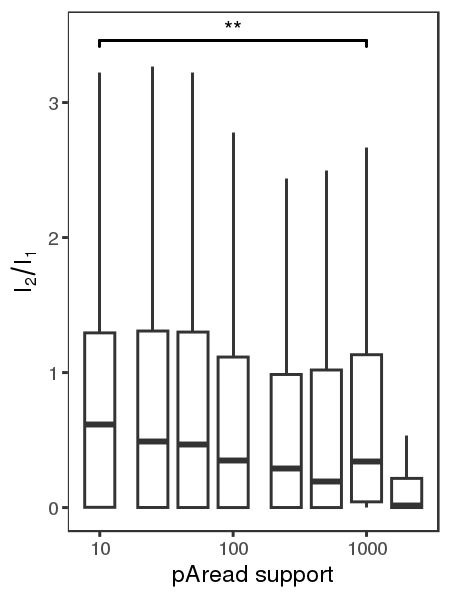

In [94]:
options(repr.plot.width = 3, repr.plot.height = 4, repr.plot.res = 150)

ate %>% 
filter(gr_50bp & (grepl(source,pat="TE")|pAread>=10|atlas_exp>=0.5)) %>% 
select(c(ex,E,gene_name,pAread)) %>% unique %>% 
inner_join(., cov_junc_exp_tis,by=join_by(ex==ex,E==E_junc,gene_name==gene_name)) %>%  

mutate(`pAread support`=case_when(
    pAread>2000 ~ 2000, pAread>1000 ~ 1000,pAread>500 ~ 500, pAread>250 ~ 250, 
    pAread>100 ~ 100,pAread>50 ~ 50,pAread>25 ~ 25, pAread>10 ~ 10)) %>% 

ggplot(.,aes(y=I2/I1,x=`pAread support`,group=`pAread support`))+
geom_boxplot(outlier.shape=NA)+

geom_signif(comparisons = list(c(1,3)), y_position=3, 
            tip_length = 0.00003, vjust=0.14, margin_top = 0.0003,
            map_signif_level = c("***"=0.001, "**"=0.01, "*"=0.05,"ns"=1.1),
            test="wilcox.test")+

coord_cartesian(ylim=c(0,3.5))+
scale_x_continuous(trans="log10")+
theme_blank+ylab(TeX("$I_2 / I_1$"))

additional filter by PAS support

In [17]:
cov_junc_exp_tis_filt <- ate %>% 
    filter(gr_50bp & (grepl(source,pat="TE")|pAread>=49|atlas_exp>=0.5)) %>% 
    select(c(ex,E,gene_name)) %>% unique %>% 
    inner_join(., cov_junc_exp_tis, 
               by=join_by(ex==ex,E==E_junc,gene_name==gene_name)) %>%  
    dplyr::rename(E_junc=E,E=`E.y`) 
    length(unique(cov_junc_exp_tis_filt$ex))

[1] 204

In [23]:
save(cov_junc_exp_tis_filt,file = "cov_junc_exp_tis_filt.PEATE_allPAS.RData")